<a href="https://colab.research.google.com/github/hamnasz/DevByte/blob/main/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks Core Setup
**DevByte AI/ML Internship — BETA Project**

**Assigned:** 2026-06-30 &nbsp;|&nbsp; **Due:** 2026-08-11

### What this notebook does
Builds a multi-layer neural network from scratch in PyTorch to classify house property rows into Budget, Mid-Range, or Premium. Trains the model, evaluates on a held-out test set, and plots the training and validation loss and accuracy curves.

### What is a Neural Network?
Think of it like a chain of filters. Each layer takes in numbers, multiplies them by learned weights, adds a bias, then passes the result through an activation function (like a volume knob that decides how loud the signal is). After many layers, the network learns which combination of features predicts each class.

### Pipeline
| Step | Task |
|---|---|
| 1 | Setup, imports, device config |
| 2 | Dataset generation |
| 3 | Preprocessing |
| 4 | PyTorch Dataset and DataLoader |
| 5 | Neural network architecture |
| 6 | Loss function, optimizer, scheduler |
| 7 | Training and validation loop |
| 8 | Loss and accuracy curves |
| 9 | Test set evaluation |
| 10 | Architecture comparison (Shallow / Medium / Deep) |
| 11 | Summary |

---
## Step 1: Imports and Device Setup

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

# Sklearn (preprocessing + metrics only)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

# Settings
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

CLASS_NAMES  = ['Budget', 'Mid-Range', 'Premium']
CLASS_COLORS = ['#4C72B0', '#55A868', '#C44E52']
NUM_CLASSES  = 3

# Use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')

PyTorch version : 2.11.0+cpu
Device          : cpu


---
## Step 2: Generate the Dataset

Same 1,200-house dataset used across all previous tasks — 9 numeric features, 3 categorical features (one-hot encoded later), and 3 balanced target classes.

In [2]:
np.random.seed(SEED)
n = 1200

area_sqft          = np.random.randint(400,  6001, n)
num_bedrooms       = np.random.randint(1,    7,    n)
num_bathrooms      = np.clip(num_bedrooms - np.random.randint(0, 2, n), 1, 5)
age_years          = np.random.randint(0,    41,   n)
distance_km        = np.round(np.random.uniform(0.5, 25.0, n), 1)
has_garden         = np.random.choice([0, 1], n, p=[0.45, 0.55])
has_parking        = np.random.choice([0, 1], n, p=[0.30, 0.70])
neighborhood_score = np.round(np.random.uniform(1.0, 10.0, n), 1)
floor_number       = np.random.randint(0, 11, n)

region        = np.vectorize({0:'Urban',1:'Suburban',2:'Rural'}.get)(
                    np.random.choice([0,1,2], n, p=[0.5,0.3,0.2]))
property_type = np.vectorize({0:'Apartment',1:'House',2:'Villa',3:'Condo'}.get)(
                    np.random.choice([0,1,2,3], n, p=[0.35,0.30,0.15,0.20]))
condition     = np.vectorize({0:'Poor',1:'Fair',2:'Good',3:'Excellent'}.get)(
                    np.random.choice([0,1,2,3], n, p=[0.10,0.25,0.40,0.25]))

rb = {'Urban':15,'Suburban':5,'Rural':-5}
tb = {'Villa':40,'House':10,'Condo':0,'Apartment':-10}
cb = {'Excellent':20,'Good':8,'Fair':-5,'Poor':-20}

noise = np.random.normal(0, 10, n)
price = (
      0.030 * area_sqft  + 8.0 * num_bedrooms + 5.0 * num_bathrooms
    - 0.8   * age_years  - 2.5 * distance_km  + 10.0 * has_garden
    + 7.0   * has_parking + 6.0 * neighborhood_score - 0.5 * floor_number
    + np.array([rb[r] for r in region])
    + np.array([tb[t] for t in property_type])
    + np.array([cb[c] for c in condition]) + noise
)
price  = np.clip(price, 15, 700)
t1, t2 = np.percentile(price, [33.3, 66.6])
target = np.where(price < t1, 0, np.where(price < t2, 1, 2))

NUM_COLS = ['area_sqft','num_bedrooms','num_bathrooms','age_years',
            'distance_km','has_garden','has_parking','neighborhood_score','floor_number']
CAT_COLS = ['region','property_type','condition']

df = pd.DataFrame({
    'area_sqft':area_sqft,'num_bedrooms':num_bedrooms,'num_bathrooms':num_bathrooms,
    'age_years':age_years,'distance_km':distance_km,'has_garden':has_garden,
    'has_parking':has_parking,'neighborhood_score':neighborhood_score,
    'floor_number':floor_number,'region':region,'property_type':property_type,
    'condition':condition,'property_class':target
})

print(f'Dataset shape : {df.shape}')
for i,name in enumerate(CLASS_NAMES):
    print(f'  {name:10s}: {(target==i).sum()} rows')
df.head(5)

Dataset shape : (1200, 13)
  Budget    : 400 rows
  Mid-Range : 399 rows
  Premium   : 401 rows


,area_sqft,num_bedrooms,num_bathrooms,age_years,distance_km,has_garden,has_parking,neighborhood_score,floor_number,region,property_type,condition,property_class
0,1260,5,5,39,2.4,1,1,1.9,8,Urban,Condo,Good,1
1,5790,3,3,11,20.8,1,0,6.2,1,Urban,Condo,Poor,2
2,5626,2,1,11,9.0,1,1,6.7,9,Urban,House,Poor,2
3,5591,2,1,14,13.3,0,1,4.3,10,Urban,House,Good,2
4,4172,3,3,40,20.0,0,0,5.8,0,Suburban,Villa,Fair,1


---
## Step 3: Preprocessing

One-hot encode the categorical columns and standard-scale all numeric columns. Then split into train (70%), validation (15%), and test (15%) sets.

In [3]:
X_raw = df.drop(columns=['property_class'])
y_raw = df['property_class'].values

# Train / val / test split first (no leakage)
X_tr_raw, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=SEED, stratify=y_raw)
X_val_raw, X_te_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# Fit preprocessor on training data only
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

X_train = preprocessor.fit_transform(X_tr_raw).astype(np.float32)
X_val   = preprocessor.transform(X_val_raw).astype(np.float32)
X_test  = preprocessor.transform(X_te_raw).astype(np.float32)

INPUT_DIM = X_train.shape[1]

print(f'Input features  : {INPUT_DIM}')
print(f'Train rows      : {len(X_train)}')
print(f'Validation rows : {len(X_val)}')
print(f'Test rows       : {len(X_test)}')

Input features  : 20
Train rows      : 840
Validation rows : 180
Test rows       : 180


---
## Step 4: PyTorch Dataset and DataLoader

PyTorch feeds data to the model in small batches. A `Dataset` wraps our arrays and a `DataLoader` handles the shuffling and batching automatically.

In [4]:
class HouseDataset(Dataset):
    """Wraps numpy arrays into a PyTorch Dataset."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_ds = HouseDataset(X_train, y_train)
val_ds   = HouseDataset(X_val,   y_val)
test_ds  = HouseDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch size      : {BATCH_SIZE}')
print(f'Train batches   : {len(train_loader)}')
print(f'Val batches     : {len(val_loader)}')

# Peek at one batch
Xb, yb = next(iter(train_loader))
print(f'\nSample batch — X shape: {Xb.shape}  |  y shape: {yb.shape}')

Batch size      : 32
Train batches   : 26
Val batches     : 6

Sample batch — X shape: torch.Size([32, 20])  |  y shape: torch.Size([32])


---
## Step 5: Neural Network Architecture

Our network is a **Multi-Layer Perceptron (MLP)** with three hidden layers. Each hidden layer has:
- A `Linear` layer (learns weights and biases)
- `BatchNorm1d` (stabilizes training by normalizing layer outputs)
- `ReLU` activation (passes positive values through, zeros out negatives)
- `Dropout` (randomly turns off neurons during training to prevent overfitting)

```
Input (20)  →  Linear(128) → BN → ReLU → Dropout(0.3)
            →  Linear(64)  → BN → ReLU → Dropout(0.2)
            →  Linear(32)  → BN → ReLU
            →  Linear(3)         ← raw scores (logits)
```

In [5]:
class PropertyMLP(nn.Module):
    """
    Flexible MLP classifier.
    hidden_dims : list of ints, e.g. [128, 64, 32]
    dropout_rate: applied after every hidden layer except the last
    """
    def __init__(self, input_dim, hidden_dims, num_classes, dropout_rate=0.3):
        super().__init__()

        layers = []
        prev   = input_dim

        for i, h in enumerate(hidden_dims):
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
            ]
            # Dropout on every hidden layer except the last one
            if i < len(hidden_dims) - 1:
                layers.append(nn.Dropout(p=dropout_rate))
            prev = h

        layers.append(nn.Linear(prev, num_classes))  # output logits
        self.net = nn.Sequential(*layers)

        # He (Kaiming) initialization for ReLU networks
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# Build the main model
model = PropertyMLP(
    input_dim    = INPUT_DIM,
    hidden_dims  = [128, 64, 32],
    num_classes  = NUM_CLASSES,
    dropout_rate = 0.3
).to(DEVICE)

print(model)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

PropertyMLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=3, bias=True)
  )
)

Total parameters     : 13,571
Trainable parameters : 13,571


---
## Step 6: Loss Function, Optimizer, and Scheduler

- **CrossEntropyLoss** — measures how wrong the predicted class probabilities are. Lower is better.
- **Adam optimizer** — adapts the learning rate per parameter automatically. Much faster than plain SGD.
- **ReduceLROnPlateau** — cuts the learning rate in half when validation loss stops improving, helping the model fine-tune without overshooting.

In [6]:
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 100
WEIGHT_DECAY  = 1e-4   # L2 regularization built into optimizer

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6
)

print(f'Criterion  : {criterion}')
print(f'Optimizer  : Adam  (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})')
print(f'Scheduler  : ReduceLROnPlateau (factor=0.5, patience=8)')
print(f'Epochs     : {NUM_EPOCHS}')

Criterion  : CrossEntropyLoss()
Optimizer  : Adam  (lr=0.001, weight_decay=0.0001)
Scheduler  : ReduceLROnPlateau (factor=0.5, patience=8)
Epochs     : 100


---
## Step 7: Training and Validation Loop

Each epoch:
1. **Train phase** — model is in `train()` mode, gradients are calculated and weights are updated
2. **Validation phase** — model is in `eval()` mode, no gradients, just measure how it performs on data it has not seen

In [7]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    """One pass through the data. If optimizer is given, runs training. Otherwise, evaluation."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            preds       = logits.argmax(dim=1)
            correct    += preds.eq(y_batch).sum().item()
            total      += X_batch.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, device=DEVICE, verbose=True):
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = run_epoch(model, val_loader,   criterion, None,      device)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f'Epoch {epoch:3d}/{num_epochs} | '
                  f'Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | '
                  f'Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f} | '
                  f'LR: {history["lr"][-1]:.6f}')

    return history

print('Training functions defined.')

Training functions defined.


In [8]:
print('Training main model (128 → 64 → 32)...')
t0      = time.time()
history = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=NUM_EPOCHS, verbose=True
)
print(f'\nTraining complete in {time.time()-t0:.1f}s')

Training main model (128 → 64 → 32)...
Epoch   1/100 | Train Loss: 1.3266  Acc: 0.3654 | Val Loss: 1.0272  Acc: 0.5167 | LR: 0.001000
Epoch  10/100 | Train Loss: 0.5310  Acc: 0.7584 | Val Loss: 0.4622  Acc: 0.8167 | LR: 0.001000
Epoch  20/100 | Train Loss: 0.3780  Acc: 0.8462 | Val Loss: 0.3204  Acc: 0.8889 | LR: 0.001000
Epoch  30/100 | Train Loss: 0.3304  Acc: 0.8606 | Val Loss: 0.2676  Acc: 0.8778 | LR: 0.001000
Epoch  40/100 | Train Loss: 0.3460  Acc: 0.8642 | Val Loss: 0.2448  Acc: 0.9056 | LR: 0.001000
Epoch  50/100 | Train Loss: 0.2810  Acc: 0.8786 | Val Loss: 0.2635  Acc: 0.8833 | LR: 0.000500
Epoch  60/100 | Train Loss: 0.2619  Acc: 0.9014 | Val Loss: 0.2434  Acc: 0.8944 | LR: 0.000250
Epoch  70/100 | Train Loss: 0.2382  Acc: 0.9062 | Val Loss: 0.2529  Acc: 0.8944 | LR: 0.000125
Epoch  80/100 | Train Loss: 0.2431  Acc: 0.9026 | Val Loss: 0.2515  Acc: 0.9056 | LR: 0.000063
Epoch  90/100 | Train Loss: 0.2342  Acc: 0.9087 | Val Loss: 0.2480  Acc: 0.9000 | LR: 0.000031
Epoch 100/1

---
## Step 8: Loss and Accuracy Curves

Plot training vs validation loss and accuracy across all epochs. A healthy model shows both curves going down and staying close together. If training loss keeps going down but validation loss starts rising, the model is overfitting.

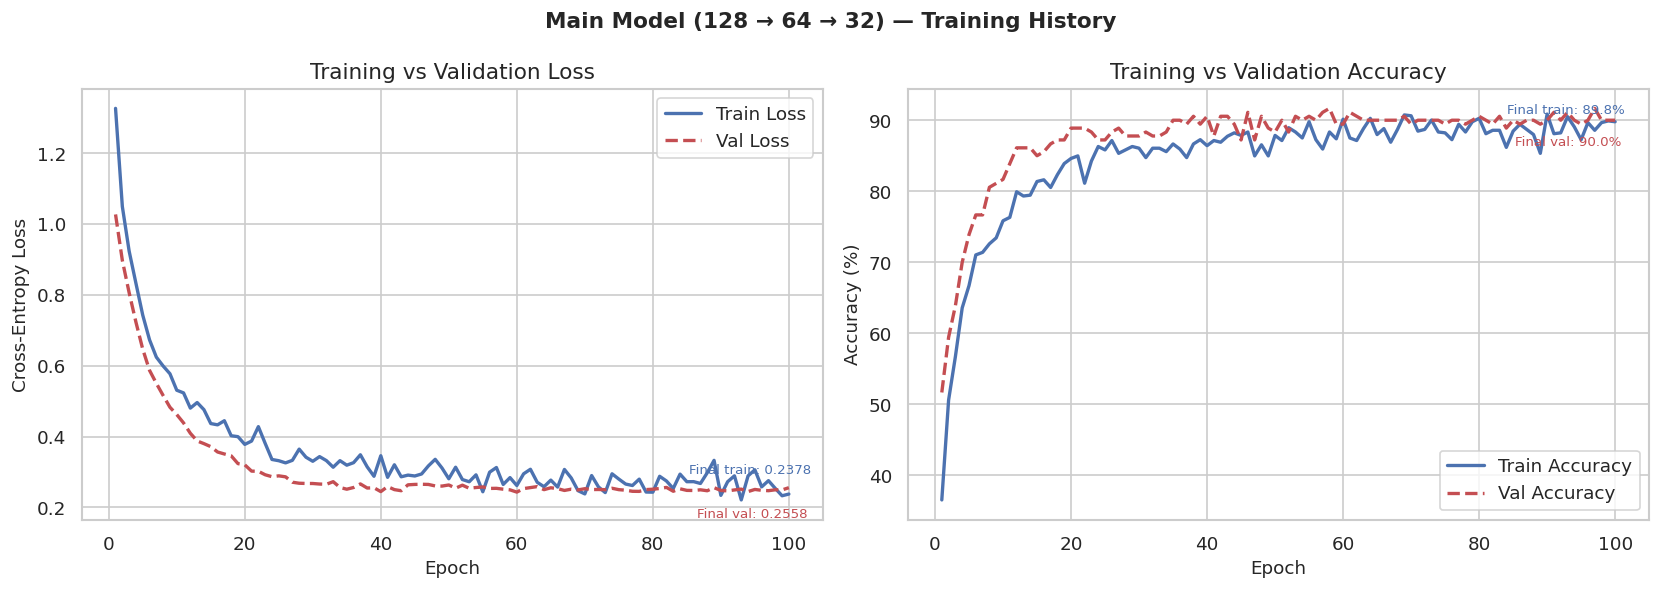

In [9]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Loss curve ----
axes[0].plot(epochs, history['train_loss'], color='#4C72B0', linewidth=2, label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   color='#C44E52', linewidth=2, label='Val Loss',   linestyle='--')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].annotate(
    f'Final train: {history["train_loss"][-1]:.4f}',
    xy=(NUM_EPOCHS, history['train_loss'][-1]),
    xytext=(-60, 12), textcoords='offset points',
    fontsize=8, color='#4C72B0'
)
axes[0].annotate(
    f'Final val: {history["val_loss"][-1]:.4f}',
    xy=(NUM_EPOCHS, history['val_loss'][-1]),
    xytext=(-55, -18), textcoords='offset points',
    fontsize=8, color='#C44E52'
)

# ---- Accuracy curve ----
axes[1].plot(epochs, [a*100 for a in history['train_acc']], color='#4C72B0', linewidth=2, label='Train Accuracy')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   color='#C44E52', linewidth=2, label='Val Accuracy',   linestyle='--')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].annotate(
    f'Final train: {history["train_acc"][-1]*100:.1f}%',
    xy=(NUM_EPOCHS, history['train_acc'][-1]*100),
    xytext=(-65, 5), textcoords='offset points',
    fontsize=8, color='#4C72B0'
)
axes[1].annotate(
    f'Final val: {history["val_acc"][-1]*100:.1f}%',
    xy=(NUM_EPOCHS, history['val_acc'][-1]*100),
    xytext=(-60, -15), textcoords='offset points',
    fontsize=8, color='#C44E52'
)

plt.suptitle('Main Model (128 → 64 → 32) — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_accuracy_curves.png', bbox_inches='tight')
plt.show()

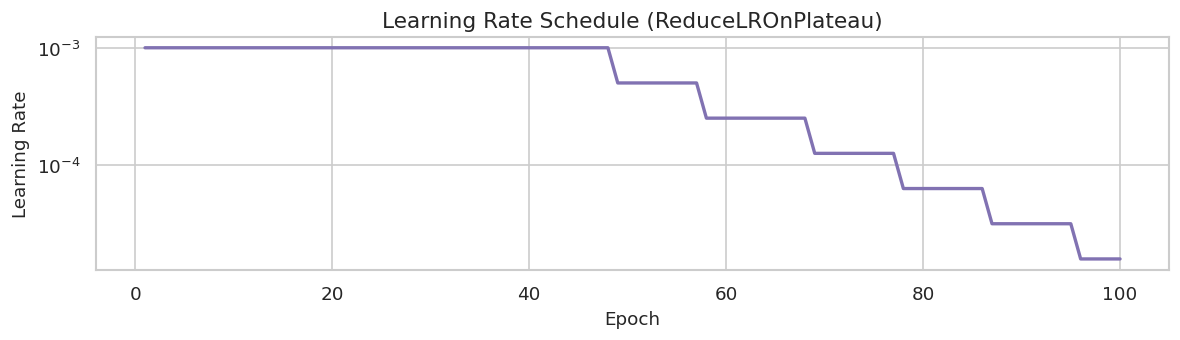

In [10]:
# Learning rate trace
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(epochs, history['lr'], color='#8172B2', linewidth=2)
ax.set_title('Learning Rate Schedule (ReduceLROnPlateau)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('lr_schedule.png', bbox_inches='tight')
plt.show()

---
## Step 9: Test Set Evaluation

The test set was never touched during training. This gives an honest picture of how the model performs on completely unseen data.

In [11]:
def get_predictions(model, loader, device=DEVICE):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits  = model(X_batch.to(device))
            probs   = torch.softmax(logits, dim=1)
            preds   = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

y_pred, y_true, y_probs = get_predictions(model, test_loader)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

print('='*55)
print('      TEST SET RESULTS — Main MLP (128→64→32)')
print('='*55)
print(f'  Accuracy           : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Weighted Precision : {prec:.4f}')
print(f'  Weighted Recall    : {rec:.4f}')
print(f'  Weighted F1        : {f1:.4f}')
print('='*55)
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

      TEST SET RESULTS — Main MLP (128→64→32)
  Accuracy           : 0.8889  (88.9%)
  Weighted Precision : 0.8901
  Weighted Recall    : 0.8889
  Weighted F1        : 0.8893

              precision    recall  f1-score   support

      Budget     0.9310    0.9000    0.9153        60
   Mid-Range     0.8226    0.8500    0.8361        60
     Premium     0.9167    0.9167    0.9167        60

    accuracy                         0.8889       180
   macro avg     0.8901    0.8889    0.8893       180
weighted avg     0.8901    0.8889    0.8893       180



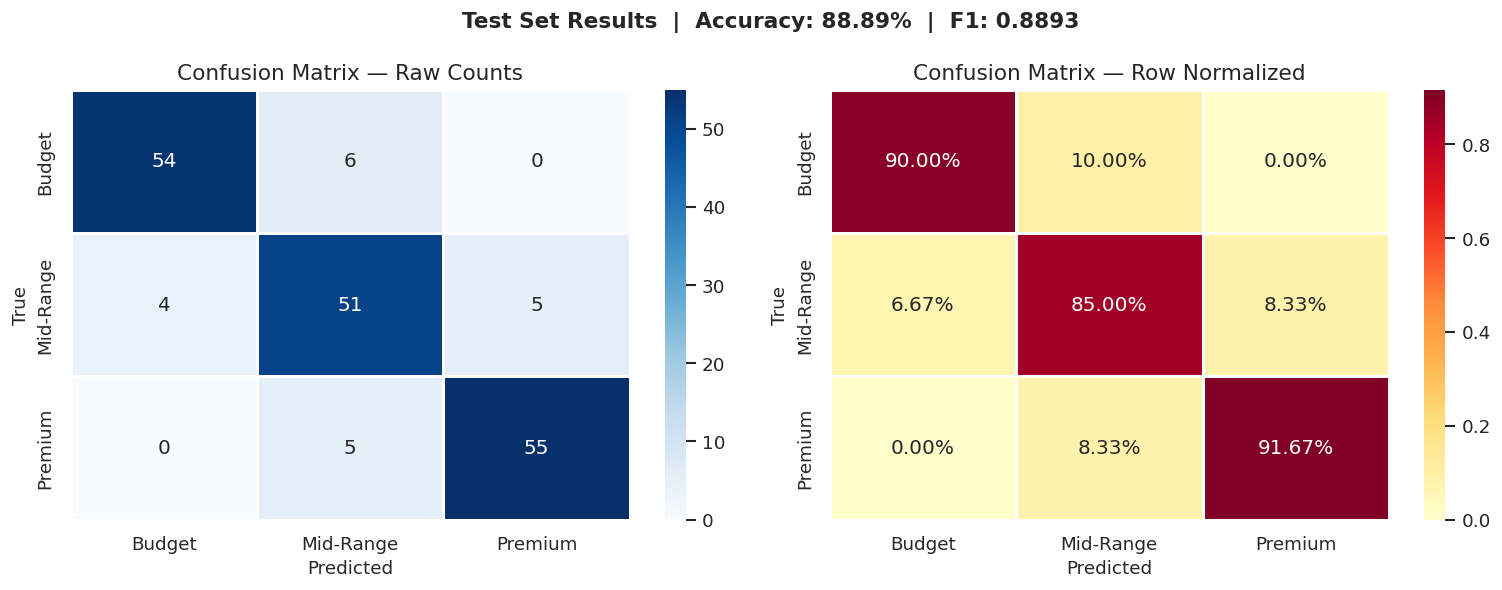

In [12]:
# Confusion matrices side by side (raw + normalized)
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, cmap, title in zip(
    axes,
    [cm,    cm_norm],
    ['d',   '.2%'],
    ['Blues','YlOrRd'],
    ['Raw Counts', 'Row Normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.8, linecolor='white',
                annot_kws={'size': 12}, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle(f'Test Set Results  |  Accuracy: {acc:.2%}  |  F1: {f1:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_confusion_matrix.png', bbox_inches='tight')
plt.show()

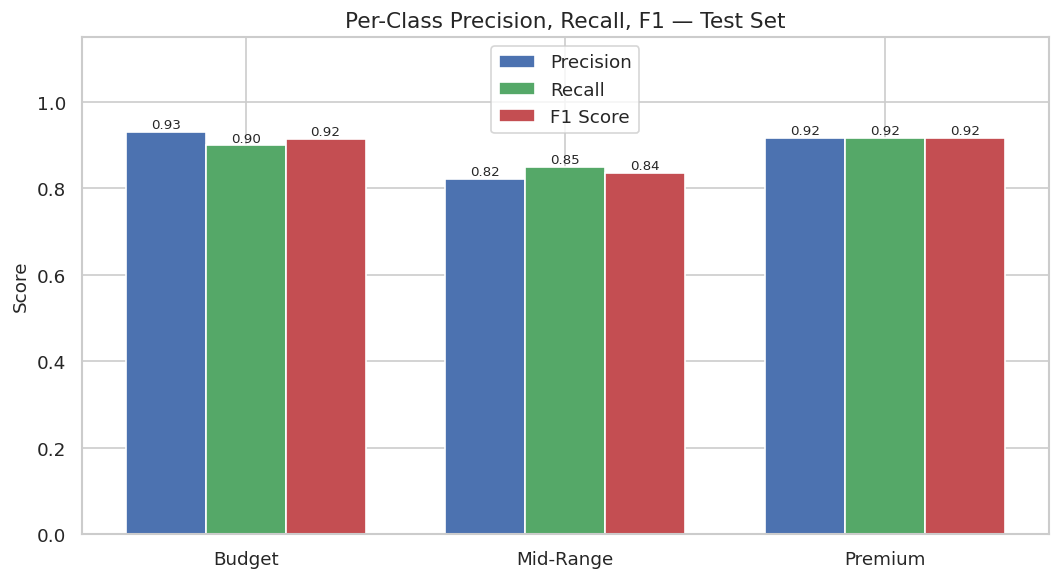

In [13]:
# Per-class precision, recall, F1 bar chart
prec_c = precision_score(y_true, y_pred, average=None)
rec_c  = recall_score(y_true,    y_pred, average=None)
f1_c   = f1_score(y_true,        y_pred, average=None)

x, w = np.arange(3), 0.25
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w, prec_c, w, label='Precision', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x,   rec_c,  w, label='Recall',    color='#55A868', edgecolor='white')
b3 = ax.bar(x+w, f1_c,   w, label='F1 Score',  color='#C44E52', edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{bar.get_height():.2f}', ha='center', fontsize=8)
ax.set_title('Per-Class Precision, Recall, F1 — Test Set')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.savefig('per_class_metrics.png', bbox_inches='tight')
plt.show()

---
## Step 10: Architecture Comparison

We train three versions of the network with different depths and compare their loss curves and final test scores side by side.

| Name | Hidden Layers | Parameters |
|---|---|---|
| Shallow | [64] | fewest |
| Medium (main) | [128, 64, 32] | balanced |
| Deep | [256, 128, 64, 32] | most |

In [14]:
ARCH_CONFIGS = {
    'Shallow [64]'          : [64],
    'Medium [128-64-32]'    : [128, 64, 32],
    'Deep [256-128-64-32]'  : [256, 128, 64, 32],
}
ARCH_COLORS  = ['#DD8452', '#4C72B0', '#55A868']
arch_results = {}

for (name, dims), color in zip(ARCH_CONFIGS.items(), ARCH_COLORS):
    print(f'Training: {name} ...', end=' ', flush=True)
    m   = PropertyMLP(INPUT_DIM, dims, NUM_CLASSES, dropout_rate=0.3).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)
    t0  = time.time()
    h   = train_model(m, train_loader, val_loader, criterion, opt, sch,
                      num_epochs=NUM_EPOCHS, verbose=False)

    yp, yt, _ = get_predictions(m, test_loader)
    arch_results[name] = {
        'history' : h,
        'acc'     : accuracy_score(yt, yp),
        'f1'      : f1_score(yt, yp, average='weighted'),
        'params'  : sum(p.numel() for p in m.parameters()),
        'time_s'  : round(time.time() - t0, 1),
        'color'   : color,
    }
    print(f'done  Acc={arch_results[name]["acc"]:.4f}  F1={arch_results[name]["f1"]:.4f}')

Training: Shallow [64] ... done  Acc=0.8722  F1=0.8724
Training: Medium [128-64-32] ... done  Acc=0.8667  F1=0.8655
Training: Deep [256-128-64-32] ... done  Acc=0.8722  F1=0.8725


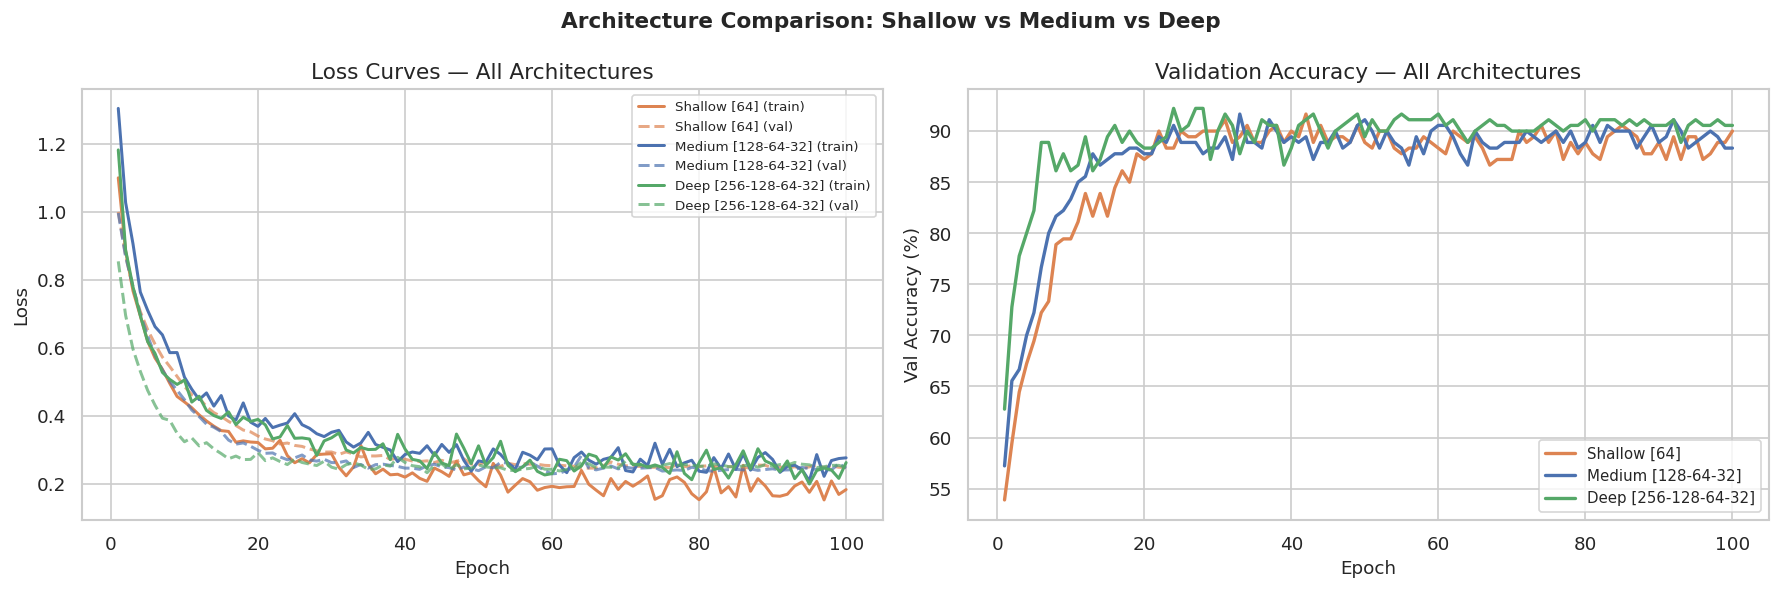

In [15]:
# Loss curves for all three architectures
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_x  = range(1, NUM_EPOCHS + 1)

for name, res in arch_results.items():
    h, col = res['history'], res['color']
    axes[0].plot(epochs_x, h['train_loss'], color=col, linewidth=1.8,
                 label=f'{name} (train)', linestyle='-')
    axes[0].plot(epochs_x, h['val_loss'],   color=col, linewidth=1.8,
                 label=f'{name} (val)',   linestyle='--', alpha=0.7)

axes[0].set_title('Loss Curves — All Architectures')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

for name, res in arch_results.items():
    h, col = res['history'], res['color']
    axes[1].plot(epochs_x, [a*100 for a in h['val_acc']], color=col,
                 linewidth=2, label=name)

axes[1].set_title('Validation Accuracy — All Architectures')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy (%)')
axes[1].legend(fontsize=9)

plt.suptitle('Architecture Comparison: Shallow vs Medium vs Deep',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('arch_comparison_curves.png', bbox_inches='tight')
plt.show()

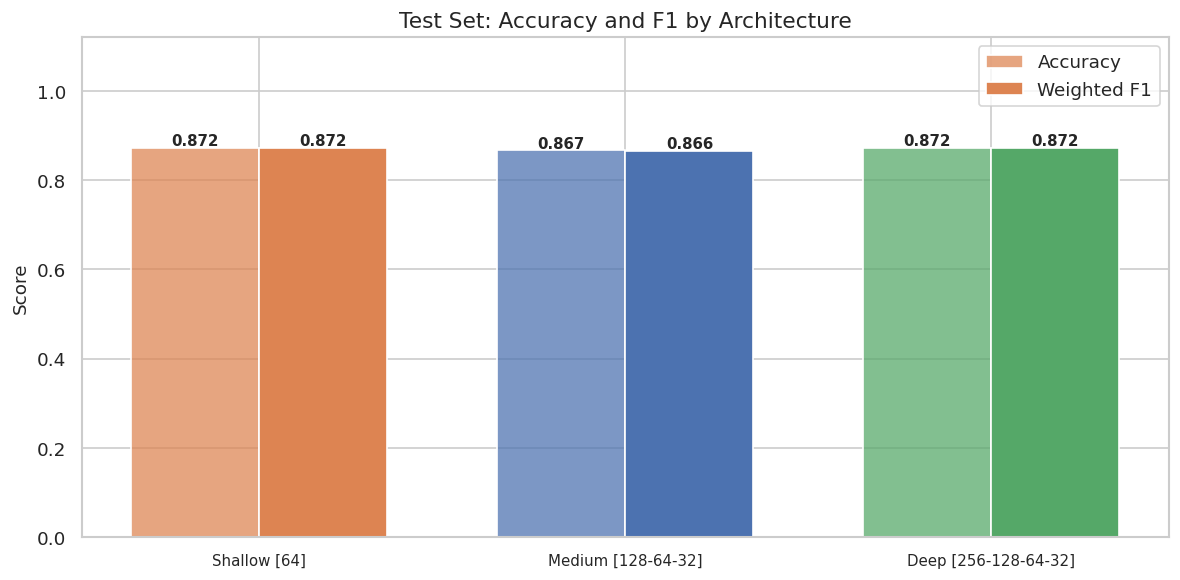

In [16]:
# Final scores bar chart
names    = list(arch_results.keys())
accs     = [arch_results[n]['acc'] for n in names]
f1s      = [arch_results[n]['f1']  for n in names]
colors   = [arch_results[n]['color'] for n in names]

x, w = np.arange(len(names)), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x-w/2, accs, w, label='Accuracy', color=[c+'BB' for c in colors], edgecolor='white')
b2 = ax.bar(x+w/2, f1s,  w, label='Weighted F1', color=colors,                edgecolor='white')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.12)
ax.set_title('Test Set: Accuracy and F1 by Architecture')
ax.legend()
plt.tight_layout()
plt.savefig('arch_comparison_scores.png', bbox_inches='tight')
plt.show()

---
## Step 11: Summary

In [17]:
print('='*72)
print('                  FINAL RESULTS SUMMARY')
print('='*72)
print(f'{"Architecture":<28} {"Params":>8}  {"Accuracy":>9}  {"W. F1":>8}  {"Time(s)":>8}')
print('-'*72)
for name, res in arch_results.items():
    print(f'{name:<28} {res["params"]:>8,}  {res["acc"]:>9.4f}  {res["f1"]:>8.4f}  {res["time_s"]:>8.1f}')
print('='*72)

best_name = max(arch_results, key=lambda n: arch_results[n]['f1'])
print(f'\nBest architecture by F1 : {best_name}')

print(f"""
NEURAL NETWORK SUMMARY

  Input features      : {INPUT_DIM}  (9 numeric + 11 OHE)
  Target classes      : {NUM_CLASSES}  (Budget, Mid-Range, Premium)
  Loss function       : CrossEntropyLoss
  Optimizer           : Adam  (lr=0.001, weight_decay=1e-4)
  Scheduler           : ReduceLROnPlateau
  Regularization      : Dropout(0.3) + BatchNorm + L2
  Weight init         : Kaiming Normal (He)
  Epochs trained      : {NUM_EPOCHS}
  Batch size          : {BATCH_SIZE}
  Device              : {DEVICE}
""")

                  FINAL RESULTS SUMMARY
Architecture                   Params   Accuracy     W. F1   Time(s)
------------------------------------------------------------------------
Shallow [64]                    1,667     0.8722    0.8724       4.9
Medium [128-64-32]             13,571     0.8667    0.8655       7.0
Deep [256-128-64-32]           49,667     0.8722    0.8725      10.4

Best architecture by F1 : Deep [256-128-64-32]

NEURAL NETWORK SUMMARY

  Input features      : 20  (9 numeric + 11 OHE)
  Target classes      : 3  (Budget, Mid-Range, Premium)
  Loss function       : CrossEntropyLoss
  Optimizer           : Adam  (lr=0.001, weight_decay=1e-4)
  Scheduler           : ReduceLROnPlateau
  Regularization      : Dropout(0.3) + BatchNorm + L2
  Weight init         : Kaiming Normal (He)
  Epochs trained      : 100
  Batch size          : 32
  Device              : cpu



---
## Quick Reference — Key Concepts

| Term | What it means |
|---|---|
| **Forward pass** | Input flows through layers to produce a prediction |
| **Loss** | A number measuring how wrong the prediction was |
| **Backpropagation** | Calculates how much each weight contributed to the loss |
| **Gradient descent** | Nudges each weight slightly to reduce the loss |
| **Epoch** | One full pass through the entire training set |
| **Batch** | A small chunk of rows processed together per step |
| **ReLU** | Activation that outputs max(0, x) — adds non-linearity |
| **BatchNorm** | Normalizes layer outputs to stabilize and speed up training |
| **Dropout** | Randomly zeros out neurons during training to prevent overfitting |
| **Softmax** | Converts raw output logits into class probabilities that sum to 1 |
| **CrossEntropyLoss** | Measures gap between predicted probabilities and true class |
| **Adam** | Smart optimizer that adjusts learning rate per parameter automatically |
| **Scheduler** | Reduces learning rate when progress stalls |
| **Overfitting** | Model learns training data too well, fails on new data |